<a href="https://colab.research.google.com/github/Irene-sketch/AI_ML_sem5/blob/main/ai_ml_cycle1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from imblearn.over_sampling import RandomOverSampler

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
import pandas as pd

df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
#1.display basic information
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.0

In [ ]:
#no of rows,colums,datatypes,missing values
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])
print(df.dtypes)


Rows: 1025
Columns: 14
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [ ]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
#display first,last and random records
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [ ]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
453,49,0,1,134,271,0,1,162,0,0.0,1,0,2,1
534,54,0,2,108,267,0,0,167,0,0.0,2,0,2,1
625,69,1,2,140,254,0,0,146,0,2.0,1,3,3,0
278,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
22,45,1,0,104,208,0,0,148,1,3.0,1,0,2,1


In [ ]:
# 4.handling missing values
df.isnull().sum()
df["age"] = df["age"].fillna(df["age"].median())

In [ ]:
#5.remove duplicate records
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

723


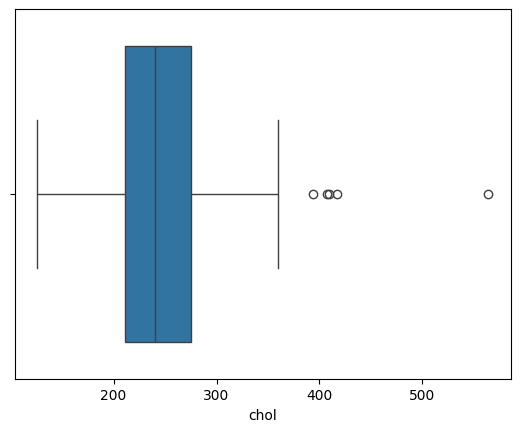

In [ ]:
Q1 = df["chol"].quantile(0.25)
Q3 = df["chol"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
sns.boxplot(x=df["chol"])
plt.show()

In [ ]:
#7.handle outliers
df = df[(df["chol"]>=lower) & (df["chol"]<=upper)]

In [ ]:
# 8. Convert Categorical Data
#Label Encoding
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])


/tmp/ipykernel_2118/2310625664.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sex"] = le.fit_transform(df["sex"])


In [ ]:
#One Hot Encoding
df = pd.get_dummies(df, columns=["cp"])

In [ ]:
#9.Feature Scaling
#min-max
mm = MinMaxScaler()

df["age"] = mm.fit_transform(df[["age"]])

In [ ]:
#standardisation
scaler = StandardScaler()

df["trestbps"] = scaler.fit_transform(df[["trestbps"]])

In [ ]:
#10.feature selection
corr = df.corr(numeric_only=True)

print(corr["target"])

age        -0.231584
sex        -0.288353
trestbps   -0.143787
chol       -0.112667
fbs        -0.035228
restecg     0.139110
thalach     0.421106
exang      -0.432968
oldpeak    -0.427227
slope       0.344538
ca         -0.401227
thal       -0.340503
target      1.000000
cp_0       -0.512992
cp_1        0.250968
cp_2        0.307078
cp_3        0.089301
Name: target, dtype: float64


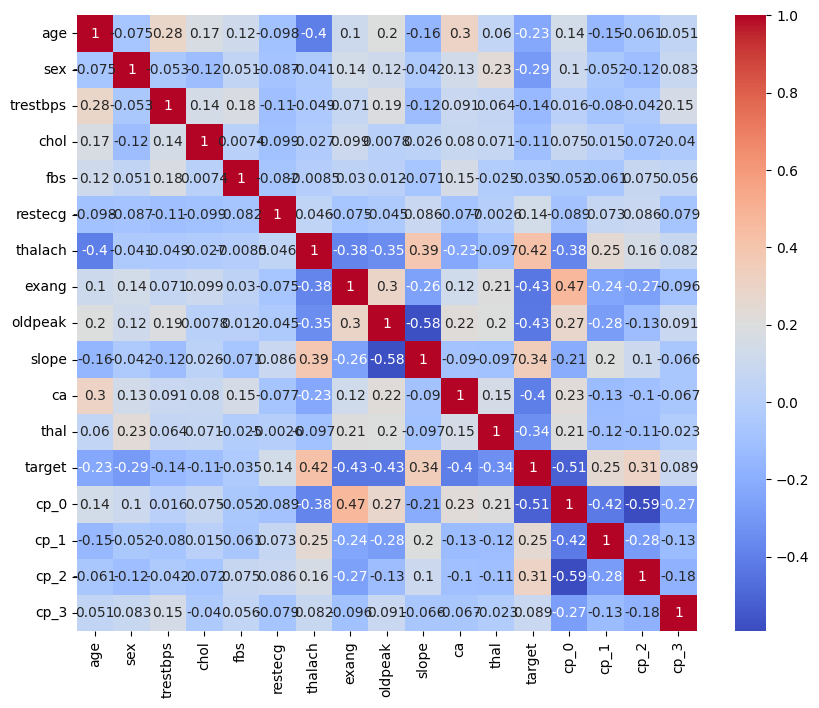

In [ ]:
# 11. Correlation Matrix and Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.show()

In [ ]:
# 12. Feature Engineering

# Create Family Size

# df["FamilySize"] = df["sibsp"] + df["parch"] + 1 # Not applicable for heart.csv

# Create IsAlone

# df["IsAlone"] = (df["FamilySize"]==1).astype(int) # Not applicable for heart.csv

### 12.1 Age Group Feature

Creating age groups can help capture non-linear relationships and segment the population. We'll categorize 'age' into 'Young', 'Middle-aged', and 'Elderly'.

In [ ]:
# Create Age Group feature
# Define original age min and max for scaling reference
original_age_min = 29 # From initial df.describe()
original_age_max = 77 # From initial df.describe()

# Calculate scaled bin edges corresponding to original age groups
scaled_bin_45 = (45 - original_age_min) / (original_age_max - original_age_min)
scaled_bin_60 = (60 - original_age_min) / (original_age_max - original_age_min)

# Define age bins for the scaled 'age' column, ensuring they are monotonically increasing
age_bins = [0, scaled_bin_45, scaled_bin_60, 1.0]
age_labels = ['Young', 'Middle-aged', 'Elderly']

df['Age_Group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False, include_lowest=True)

# Convert Age_Group to numerical using Label Encoding if preferred for models, or one-hot encode later.
# For now, let's keep it categorical for readability and potential one-hot encoding after train-test split.

print("Age_Group distribution:")
display(df['Age_Group'].value_counts())
display(df.head())

Age_Group distribution:


,count
Age_Group,
Middle-aged,156
Elderly,86
Young,55


,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_0,cp_1,cp_2,cp_3,High_Cholesterol,Hypertension,Age_Group
0,0.479167,1,-0.370956,212,0,1,168,0,1.0,2,2,3,0,True,False,False,False,1,0,Middle-aged
1,0.500000,1,0.480904,203,1,0,155,1,3.1,0,0,3,0,True,False,False,False,1,0,Middle-aged
2,0.854167,1,0.764857,174,0,1,125,1,2.6,0,0,3,0,True,False,False,False,0,0,Elderly
3,0.666667,1,0.935229,203,0,1,161,0,0.0,2,1,3,0,True,False,False,False,1,0,Elderly
4,0.687500,0,0.367323,294,1,1,106,0,1.9,1,3,2,0,True,False,False,False,1,0,Elderly


### 12.2 Medical Threshold Indicators

We can create binary features based on common medical thresholds for cholesterol and blood pressure, as these are critical factors in heart health.

In [ ]:
# Create High Cholesterol indicator (e.g., chol > 200 is often considered high)
df['High_Cholesterol'] = (df['chol'] > 200).astype(int)

# Create Hypertension indicator (e.g., trestbps >= 140 is often considered hypertension)
df['Hypertension'] = (df['trestbps'] >= 140).astype(int)

print("High_Cholesterol distribution:")
display(df['High_Cholesterol'].value_counts())

print("Hypertension distribution:")
display(df['Hypertension'].value_counts())

display(df.head())

High_Cholesterol distribution:


,count
High_Cholesterol,
1,247
0,50


Hypertension distribution:


,count
Hypertension,
0,297


,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_0,cp_1,cp_2,cp_3,High_Cholesterol,Hypertension
0,0.479167,1,-0.370956,212,0,1,168,0,1.0,2,2,3,0,True,False,False,False,1,0
1,0.500000,1,0.480904,203,1,0,155,1,3.1,0,0,3,0,True,False,False,False,1,0
2,0.854167,1,0.764857,174,0,1,125,1,2.6,0,0,3,0,True,False,False,False,0,0
3,0.666667,1,0.935229,203,0,1,161,0,0.0,2,1,3,0,True,False,False,False,1,0
4,0.687500,0,0.367323,294,1,1,106,0,1.9,1,3,2,0,True,False,False,False,1,0


In [ ]:
#13. Convert Data Types
df["age"] = df["age"].astype(float)

In [ ]:
# 14. Handle Inconsistent Data


df.columns = df.columns.str.lower()

# df["class"] = df["class"].str.strip() # 'class' column does not exist in heart.csv

# Remove spaces

df = df.replace(r'^\s*$', np.nan, regex=True)

In [ ]:
# 15. Split Dataset
X = df.drop("target",axis=1)

y = df["target"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(237, 19)
(60, 19)


In [ ]:
#16. Balance Dataset
ros = RandomOverSampler(random_state=42)

X_train,y_train = ros.fit_resample(X_train,y_train)

print(y_train.value_counts())

target
1    126
0    126
Name: count, dtype: int64


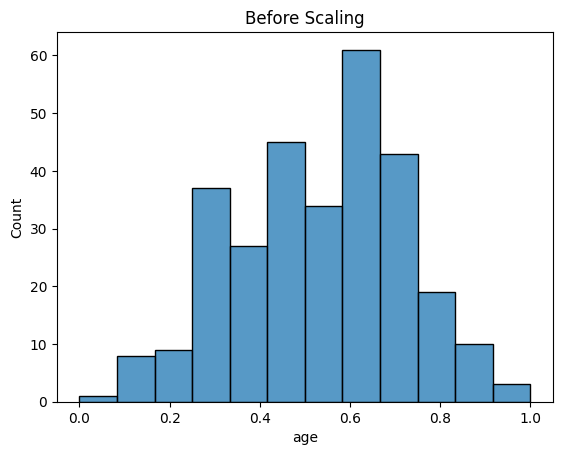

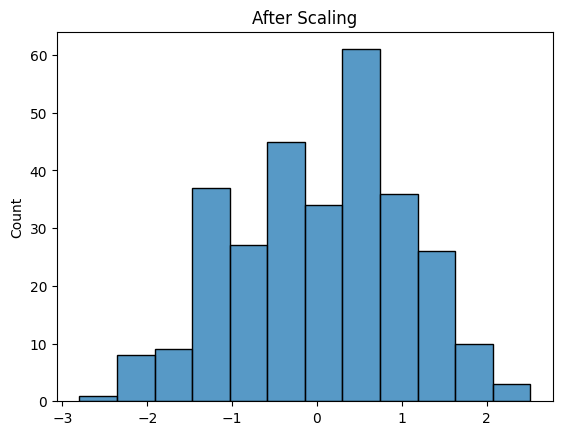

In [ ]:
#17. Distribution Before and After Scaling

# Before

sns.histplot(df["age"])

plt.title("Before Scaling")

plt.show()

#After
scaled = StandardScaler().fit_transform(df[["age"]])

sns.histplot(scaled.flatten())

plt.title("After Scaling")

plt.show()

In [ ]:
print("Original Shape:",pd.read_csv("heart.csv").shape)

print("Processed Shape:",df.shape)

# Or

print(df.describe())

Original Shape: (1025, 14)
Processed Shape: (297, 20)
              age         sex      trestbps        chol         fbs  \
count  297.000000  297.000000  2.970000e+02  297.000000  297.000000   
mean     0.526726    0.693603  8.971499e-18  243.272727    0.148148   
std      0.188499    0.461775  1.001688e+00   44.996731    0.355846   
min      0.000000    0.000000 -2.131466e+00  126.000000    0.000000   
25%      0.375000    0.000000 -6.549090e-01  211.000000    0.000000   
50%      0.541667    1.000000 -8.700251e-02  240.000000    0.000000   
75%      0.666667    1.000000  4.809040e-01  273.000000    0.000000   
max      1.000000    1.000000  3.888343e+00  360.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean     0.535354  149.468013    0.329966    1.028620    1.400673    0.710438   
std      0.525944   23.078446    0.470994    1.156805    0.6187

In [ ]:
#19. Save Clean Dataset
df.to_csv("cleaned_heart.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
## Step 20: Summary

# The following preprocessing operations were successfully completed:

# - Loaded the dataset
# - Explored the dataset
# - Identified and handled missing values
# - Removed duplicate records
# - Detected and treated outliers
# - Encoded categorical variables
# - Applied feature scaling
# - Performed feature selection
# - Generated a correlation heatmap
# - Created new features
# - Converted data types
# - Cleaned inconsistent data
# - Split the dataset into training and testing sets
# - Balanced the training data
# - Visualized feature distributions
# - Compared the dataset before and after preprocessing
# - Saved the cleaned dataset